# <center>**Enhancing LEM-X Imaging with the IROS Reconstruction Pipeline**<center>

## <center>**Source Modelling**<center>

In [1]:
from pathlib import Path
from typing import Any, Callable

import numpy as np
from numpy.typing import NDArray
import matplotlib as mpl
import matplotlib.pyplot as plt

from bloodmoon.io import simulation_files
from bloodmoon.mask import CodedMaskCamera, codedmask
from bloodmoon.mask import count, decode, variance
from bloodmoon.optim import model_sky
import darksun as ds

from IROSrec.handle import config_dirpaths
import imgmaker as mgm

plt.rcdefaults()

RCPARAMS = {
    'axes.formatter.limits': (-3, 3),
    'savefig.bbox': 'tight',
}
mpl.rcParams.update(RCPARAMS)

In [ ]:
MASK_FITS: str = "mask_NTHT_20260129_CORRECTED.fits"
UPS_X, UPS_Y = 2, 1

SKYFIELD: str = "IROSDummy"
DATA_FITS: str = "iros_benchmark_2-50keV_mask_050_1040x17_1ks"

RUN_ID: str = 'Crab_benchmark_2-50keV'
E_min, E_max = 2.0, 50.0           # [keV]

ID_CAMERA_A: str = "cam1a"
# ID_CAMERA_B: str = "cam1b"

In [10]:
MASK_PATH, SIMUL_DATA_PATH, SAVE_PATH = config_dirpaths(
    mask=MASK_FITS,
    skyfield=SKYFIELD,
    simul=DATA_FITS,
    runID=RUN_ID,
)
OUT_RESULTS_PATH = mgm.config_savedata_to()

wfm: CodedMaskCamera = codedmask(MASK_PATH, UPS_X, UPS_Y)

filepaths: dict[str, dict[str, Path]] = simulation_files(SIMUL_DATA_PATH)
sdlA = ds.get_data(filepaths[ID_CAMERA_A]["reconstructed"], E_min=E_min, E_max=E_max)
catA = ds.get_catalogue(filepaths[ID_CAMERA_A]['sources'])
# sdlB = ds.get_data(filepaths[ID_CAMERA_B]["reconstructed"], E_min=E_min, E_max=E_max)
# catB = ds.get_catalogue(filepaths[ID_CAMERA_B]['sources'])

logA, _ = ds.load_database(f"{SAVE_PATH}/IROS_sources_db.fits")

# Loading data...
# Loading completed!


In [11]:
detector, _ = count(wfm, sdlA.DLdata)
varmap = variance(wfm, detector)
true_skyA = decode(wfm, detector)

In [12]:
from bloodmoon.images import argmax

IDX: int = 0   # s17

SRC_DATA = {
    'sx': logA.log['shift_x'][IDX],
    'sy': logA.log['shift_y'][IDX],
    'cts': logA.log['fluence'][IDX],
    'pos': argmax(true_skyA), #(logA.log['y'][IDX], logA.log['x'][IDX]),
    'crp': (40, 5),
}

template = model_sky(wfm, SRC_DATA['sx'], SRC_DATA['sy'], SRC_DATA['cts'])
src_psf, src_model = map(lambda x: ds.crop(x, SRC_DATA['pos'], SRC_DATA['crp']), (true_skyA, template))

In [13]:
def set_phase(x: NDArray) -> NDArray:
    """Centers x values around zero."""
    return np.arange(len(x) + 1) - len(x) // 2 - 0.5
    
def find_tick_val(ticks: NDArray, trg_vals: NDArray, atol: float = 1e-2) -> NDArray:
    """Finds the idxs inside `ticks` relative to given values `trg_vals`."""
    trg_idxs: list[int] = []
    for v in trg_vals:
        idx = np.argwhere(np.isclose(ticks, v, atol=atol))
        if idx.size > 0: trg_idxs.append(idx[0, 0])
    return np.array(trg_idxs)

def show_SPSF(
    camera: CodedMaskCamera,
    psf: NDArray,
    modelled: NDArray,
    save_to: str | None = None,
    save_options: dict[str, Any] | None = None,
    **fig_kws,
) -> None:
    """
    Plots the SPSF heat maps and profiles along fine/coarse axes + cfr with modelled source.
    """
    title_fs = 16
    lbl_fs = 14
    # setup
    dtx, dty = ds.pixels_angular_resolution(camera, verbose=False)
    residues = (psf - modelled) * 100 / psf.max()
    n, m = psf.shape
    xslice, yslice = zip(
        *tuple((c[(n - 1) // 2, :], c[:, (m - 1) // 2]) for c in (psf, modelled, residues))
    )
    slice_clrs = ('OrangeRed', 'DodgerBlue')
    # plot figure
    fig, axs = plt.subplots(2, 3, tight_layout=True, **fig_kws)
    axs = axs.flatten()
    
    # ------------------------ SPFS HEAT MAPS ------------------------
    img_layout = {'origin': 'lower', 'interpolation': 'none', 'aspect': 2 * m / n}
    yticks, xticks = map(lambda s: np.arange(0, s), psf.shape)
    _ytick_lbls, _xtick_lbls = (
        dty / 60 * (yticks - len(yticks) // 2), dtx * (xticks - len(xticks) // 2),
    )
    yticks_ = find_tick_val(_ytick_lbls, np.array([-5.0, -2.5, 0.0, 2.5, 5.0]), atol=7e-2)
    yticks_lbl = [float(f'{t:.1f}') for t in _ytick_lbls[yticks_]]
    xticks_ = find_tick_val(_xtick_lbls, np.array([-6.35, 0.0, 6.35]), atol=1e-3)
    xticks_lbl = [float(f'{t:.1f}') for t in _xtick_lbls[xticks_]]

    axs[0].set_title('Crab SPFS', fontsize=title_fs)
    psf_img = axs[0].imshow(psf, cmap='gist_heat', **img_layout)
    cbar = fig.colorbar(psf_img, ax=axs[0], location='right', shrink=0.8, pad=0.05)
    cbar.set_label('counts [ph]', fontsize=lbl_fs)
    cbar.ax.tick_params(labelsize=lbl_fs)
    axs[0].set_xlabel(xlabel='$\\Delta\\theta_{fine}$ [arcmin]', fontsize=lbl_fs)
    axs[0].set_ylabel(ylabel='$\\Delta\\theta_{coarse}$ [deg]', fontsize=lbl_fs)

    axs[3].set_title('Crab SPFS Residues', fontsize=title_fs)
    mod_img = axs[3].imshow(residues, **img_layout)
    cbar = fig.colorbar(mod_img, ax=axs[3], location='right', shrink=0.8, pad=0.05)
    cbar.set_label('residues counts [%]', fontsize=lbl_fs)
    cbar.ax.tick_params(labelsize=lbl_fs)
    axs[3].set_xlabel(xlabel='$\\Delta\\theta_{fine}$ [arcmin]', fontsize=lbl_fs)
    axs[3].set_ylabel(ylabel='$\\Delta\\theta_{coarse}$ [deg]', fontsize=lbl_fs)

    for idx in [0, 3]:
        axs[idx].set_xticks(xticks_, xticks_lbl)
        axs[idx].set_yticks(yticks_, yticks_lbl)

    # ------------------------ SPFS PROFILES | FINE AXIS ------------------------
    x = dtx * set_phase(xslice[0])

    axs[1].set_title('SPFS Slice - Fine Axis', fontsize=title_fs)
    axs[1].stairs(xslice[0], edges=x, edgecolor=slice_clrs[0], label='true')
    axs[1].stairs(xslice[1], edges=x, edgecolor=slice_clrs[1], label='modelled')
    # axs[1].set_ylim(-3e4, None)
    axs[1].set_xlabel(xlabel='$\\Delta\\theta_{fine}$ [arcmin]', fontsize=lbl_fs)
    axs[1].yaxis.tick_right()

    axs[4].set_title('SPFS Slice Residues - Fine Axis', fontsize=title_fs)
    axs[4].plot(x, np.zeros_like(x), slice_clrs[0], label='ground', linestyle='--', alpha=0.6)
    axs[4].stairs(xslice[2], edges=x, edgecolor=slice_clrs[1], label='residues')
    axs[4].set_xlabel(xlabel='$\\Delta\\theta_{fine}$ [arcmin]', fontsize=lbl_fs)
    axs[4].yaxis.tick_right()

    # ------------------------ SPFS PROFILES | COARSE AXIS ------------------------
    x = dty * set_phase(yslice[0]) / 60

    axs[2].set_title('SPFS Slice - Coarse Axis', fontsize=title_fs)
    axs[2].stairs(yslice[0], edges=x, edgecolor=slice_clrs[0], label='true')
    axs[2].stairs(yslice[1], edges=x, edgecolor=slice_clrs[1], label='modelled')
    # axs[2].set_ylim(-3e4, None)
    axs[2].set_xlabel(xlabel='$\\Delta\\theta_{coarse}$ [deg]', fontsize=lbl_fs)
    axs[2].set_ylabel(ylabel='counts [ph]', labelpad=10, fontsize=lbl_fs)
    axs[2].yaxis.set_label_position('right')
    axs[2].yaxis.tick_right()

    axs[5].set_title('SPFS Slice Residues - Coarse Axis', fontsize=title_fs)
    axs[5].plot(x, np.zeros_like(x), slice_clrs[0], label='ground', linestyle='--', alpha=0.6)
    axs[5].stairs(yslice[2], edges=x, edgecolor=slice_clrs[1], label='residues')
    axs[5].set_xlabel(xlabel='$\\Delta\\theta_{coarse}$ [deg]', fontsize=lbl_fs)
    axs[5].set_ylabel(ylabel=r'residues counts [%]', labelpad=10, fontsize=lbl_fs)
    axs[5].yaxis.set_label_position('right')
    axs[5].yaxis.tick_right()


    for ax in axs:
        ax.xaxis.set_ticks_position('both')
        ax.yaxis.set_ticks_position('both')
        ax.tick_params(which='both', direction='in', width=1.5, length=4 if 'major' else 2.5, labelsize=lbl_fs)
    for idx in [1, 2, 4, 5]:
        axs[idx].legend(loc='best')

    if save_to is not None:
        save_options_ = save_options or {}
        fig.savefig(save_to, **save_options_)
    
    plt.show()
    return

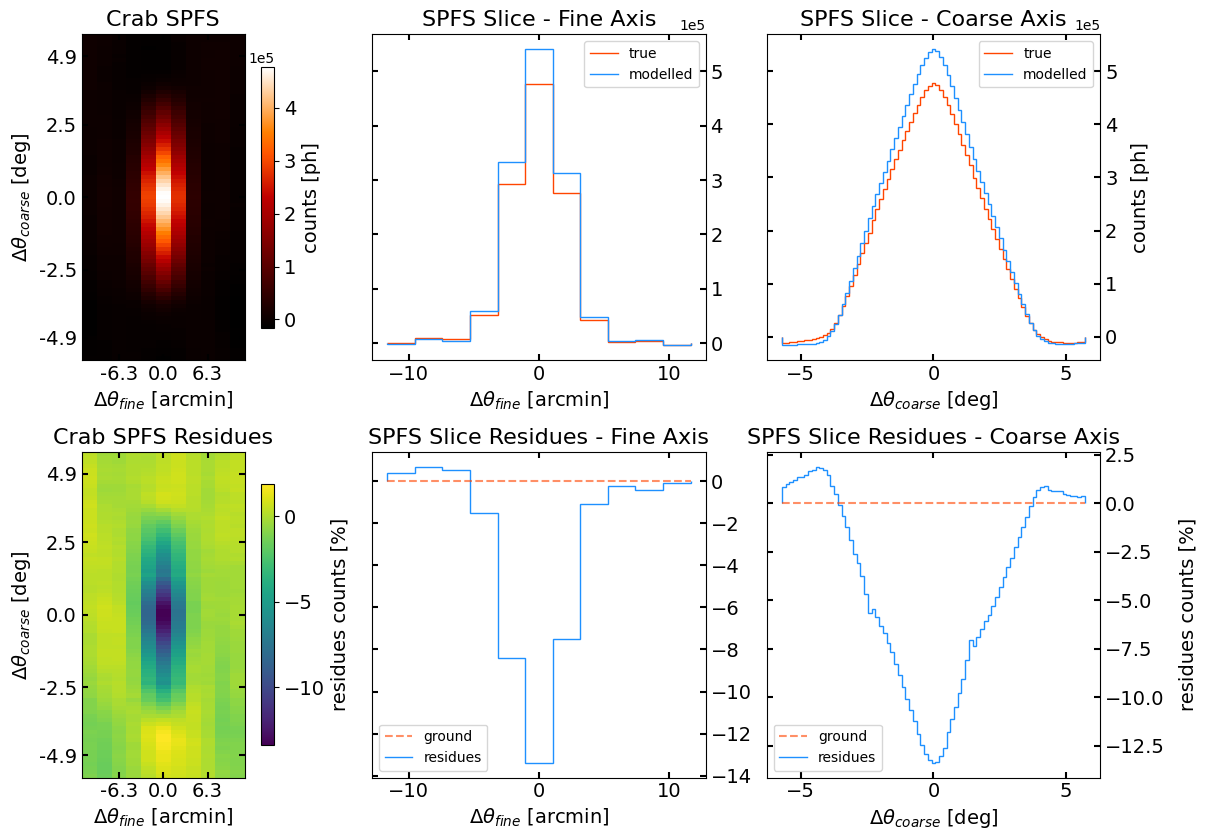

In [14]:
show_SPSF(
    camera=wfm,
    psf=src_psf,
    modelled=src_model,
    save_to=f'{OUT_RESULTS_PATH}/Crab_1ks_{E_min}-{E_max}keV.pdf',
    figsize=(4 * 3 + 0.5, 4 * 2 + 0.5),
)

<br>

<br>

<br>

## <center>**Instrumental Effects**<center>

In [15]:
DO_INSTR_EFFS: bool = False

if not DO_INSTR_EFFS:
    raise Exception

Exception: 

In [ ]:
from bloodmoon.coords import equatorial2pos
from bloodmoon.types import CoordEquatorial
from darksun.data import CatalogueLoader, DataLoader
from darksun.benchmarking import source_catalogue_data

type EnergyRange = tuple[float | None, float | None]

def get_source_coords(
    sourceID: str,
    catalogue: CatalogueLoader,
) -> CoordEquatorial:
    """Retrieves the source RA/Dec coords from catalogue."""
    data = source_catalogue_data(sourceID, catalogue.DLdata)
    return CoordEquatorial(data['RA'], data['DEC'])

def gen_source_sg(
    coords: CoordEquatorial,
    sdl: DataLoader,
    camera: CodedMaskCamera,
    E_min: float | None = None,
    E_max: float | None = None,
) -> NDArray:
    """Generates the source shadowgram from the photons in given energy range."""
    # retrieve all photons from selected direction
    source_photons = ds.select_source_photons(coords, sdl.DLdata, False)
    # select photons in input energy range
    filtered = ds.filter_data(source_photons, E_min=E_min, E_max=E_max, coords=None)
    # remove photons fell in detector plane dead zone
    sg = count(camera, filtered)[0] * (camera.bulk > 0)
    return sg

def gather_spsf_ebands(
    sourceID: str,
    catalogue: CatalogueLoader,
    sdl: DataLoader,
    camera: CodedMaskCamera,
    energy_range: EnergyRange | tuple[EnergyRange, ...],
) -> list[NDArray]:
    """Generates sky images in given energy bands."""
    energy_range_ = (
        (energy_range,) if isinstance(energy_range[0], (float | None)) else energy_range
    )
    coords = get_source_coords(sourceID, catalogue)
    skies = [
        decode(camera, gen_source_sg(coords, sdl, camera, emin, emax)) for (emin, emax) in energy_range_
    ]
    return skies

In [ ]:
wfm_up: CodedMaskCamera = codedmask(MASK_PATH, 10, 1, hide_bulk_els_y=1.0)
sdl_detected = ds.get_data(filepaths[ID_CAMERA_A]["detected"])
sdl_reconstructed = ds.get_data(filepaths[ID_CAMERA_A]["reconstructed"])

print('Modelling templates...')
template_thin = model_sky(wfm_up, SRC_DATA['sx'], SRC_DATA['sy'], SRC_DATA['cts'], vignetting=False, psfy=False)
template = model_sky(wfm_up, SRC_DATA['sx'], SRC_DATA['sy'], SRC_DATA['cts'], psfy=False)

print('Generating true skies...')
detected, reconstructed = map(lambda phs: count(wfm_up, phs)[0], (sdl_detected.DLdata, sdl_reconstructed.DLdata))
sky_detected, sky_reconstructed = map(lambda detector: decode(wfm_up, detector), (detected, reconstructed))

print('Baking SPSF energy components...')
energy_range: tuple[EnergyRange, ...] = (
    (2.0, 4.0), (4.0, 6.0), (6.0, 10.0), (10.0, 20.0), (20.0, 50.0),
)
eband_skies = gather_spsf_ebands(logA.log['ID'][IDX], catA, sdl_reconstructed, wfm_up, energy_range)

Modelling templates...
UserInfo: using bulk mask of [0.0 x 1.5] mm.
Generating true skies...
Baking SPSF energy components...


In [ ]:
UP_POS = equatorial2pos(sdlA, wfm_up, *get_source_coords(logA.log['ID'][IDX], catA))
UP_CRP = (SRC_DATA['crp'][0] * (wfm_up.upscale_f.y - UPS_Y + 1), 2 * (wfm_up.upscale_f.x - UPS_X + 1) + 1)

sky_ids = [
    'thin', 'vignetted', 'detected', 'reconstructed',
]
sky_list = [
    template_thin, template, sky_detected, sky_reconstructed,
]
crp_skies = {
    sky_id: ds.crop(sky, UP_POS, UP_CRP) for sky_id, sky in zip(sky_ids, sky_list)
}
crp_skies['ebands'] = {eband: ds.crop(sky, UP_POS, UP_CRP) for eband, sky in zip(energy_range, eband_skies)}

In [ ]:
def show_instr_effects(
    camera: CodedMaskCamera,
    skies: dict[str, NDArray | dict],
    save_to: str | None = None,
    save_options: dict[str, Any] | None = None,
    **fig_kws,
) -> None:
    """
    Triple plot with vignetting, detector finite resolution and inclined penetration effects on SPSF.
    """
    def get_slices(sky: NDArray) -> tuple[NDArray, NDArray]:
        """Crops sky array and extracts fine/coarse axis slice."""
        n, m = sky.shape
        return sky[(n - 1) // 2, :], sky[:, (m - 1) // 2]
    
    title_fs = 16
    lbl_fs = 14
    slice_clrs = ('OrangeRed', 'DodgerBlue')
    ebands_clrs = ('OrangeRed', 'Orange', 'Green', 'DodgerBlue', 'DarkViolet')
    dtx, dty = ds.pixels_angular_resolution(camera, verbose=False)
    # plot figure
    fig, axs = plt.subplots(1, 3, tight_layout=True, **fig_kws)
    axs = axs.flatten()

    # ------------------------ VIGNETTING ------------------------
    xslice_thin, xslice = map(lambda sky: get_slices(skies[sky])[0], ('thin', 'vignetted'))
    x = dtx * set_phase(xslice_thin)

    axs[0].set_title('Vignetting', fontsize=title_fs)
    axs[0].stairs(xslice_thin, edges=x, edgecolor=slice_clrs[0], label='ideal')
    axs[0].stairs(xslice, edges=x, edgecolor=slice_clrs[1], label='vignetted')
    axs[0].set_xlabel(xlabel='$\\Delta\\theta_{fine}$ [arcmin]', fontsize=lbl_fs)
    axs[0].set_ylabel(ylabel='counts [ph]', fontsize=lbl_fs)

    # ------------------------ DETECTOR RESOLUTION ------------------------
    yslice_det, yslice_rec = map(lambda sky: get_slices(skies[sky])[1], ('detected', 'reconstructed'))
    x = dty / 60 * set_phase(yslice_det)

    axs[1].set_title('Detector Finite Res.', fontsize=title_fs)
    axs[1].stairs(yslice_det, edges=x, edgecolor=slice_clrs[0], label='ideal')
    axs[1].stairs(yslice_rec, edges=x, edgecolor=slice_clrs[1], label='real')
    axs[1].set_xlabel(xlabel='$\\Delta\\theta_{coarse}$ [deg]', fontsize=lbl_fs)
    # axs[1].set_ylabel(ylabel='counts [ph]', fontsize=lbl_fs)

    # ------------------------ INCLINED PENETRATION ------------------------
    ebands_dmap = skies['ebands']
    eband_xslices = tuple(get_slices(sky)[0] for sky in ebands_dmap.values())
    eband_lbls = tuple(
        f'{int(emin) or 2}-{int(emax) or 50} keV' for (emin, emax) in ebands_dmap.keys()
    )
    x = dtx * set_phase(eband_xslices[0])

    axs[2].set_title('Inclined Penetration', fontsize=title_fs)
    for xs, lbl, clr in zip(eband_xslices, eband_lbls, ebands_clrs):
        axs[2].stairs(xs, edges=x, edgecolor=clr, label=lbl)
    axs[2].set_xlabel(xlabel='$\\Delta\\theta_{fine}$ [arcmin]', fontsize=lbl_fs)
    # axs[2].set_ylabel(ylabel='counts [ph]', fontsize=lbl_fs)
    
    for ax in axs:
        ax.xaxis.set_ticks_position('both')
        ax.yaxis.set_ticks_position('both')
        ax.tick_params(which='both', direction='in', width=1.5, length=4 if 'major' else 2.5, labelsize=lbl_fs)
        ax.legend(loc='best')
    
    for idx in [0, 1]: axs[idx].set_ylim(-4.5e4, None)

    if save_to is not None:
        save_options_ = save_options or {}
        fig.savefig(save_to, **save_options_)
    
    plt.show()
    return

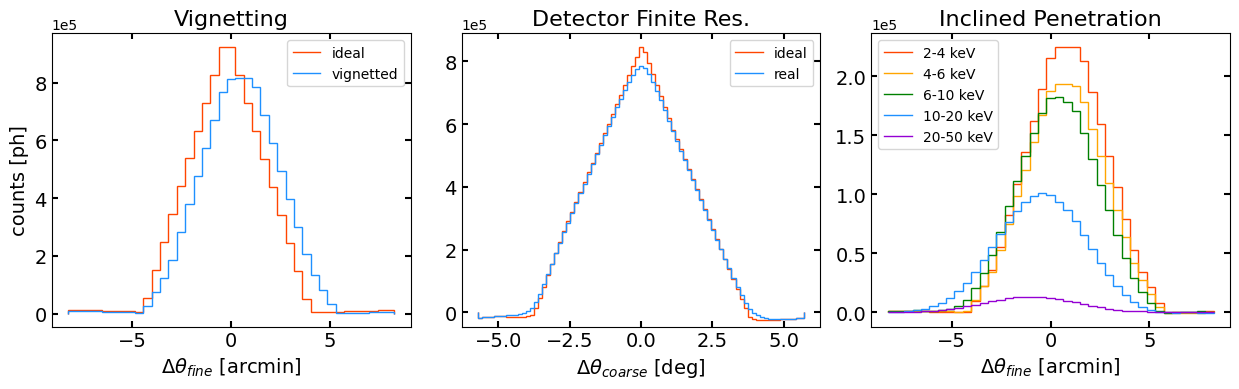

In [ ]:
show_instr_effects(
    camera=wfm_up,
    skies=crp_skies,
    save_to=f'{OUT_RESULTS_PATH}/instr_effects.pdf',
    figsize=(4 * 3 + 0.5, 4),
)